# Late-Delivery Prediction & Operational Segments — Data Science & AI/ML (Set C)

| | |
|---|---|
| **Student name** | MAITRAK KUNJADIYA |
| **Student ID** | 10015 |
| **Set** | C (Predict late deliveries and identify operational segments) |


## Section 0 — Setup, data generation and F1 (audit & partition)

### 0.1 Imports, seeds, folders, library versions

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_b.csv", index=False)


In [4]:
df = pd.read_csv("data/raw/set_b.csv")

print(df.head())

print("\nShape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget counts:")
print(df["late"].value_counts())

print("\nDuplicate rows:", df.duplicated().sum())

df_clean = df.drop_duplicates().copy()

print("Before:", df.shape)
print("After :", df_clean.shape)

print("Unique records:",
      df_clean["record_id"].nunique())

   record_id  distance   load  traffic  staff group  late
0          1     68.12  42.71    39.14  45.98    G2     1
1          2     38.47  65.08    58.80  56.38    G1     1
2          3     64.10  43.99    36.86  53.47    G2     0
3          4     53.09  41.44    55.36  64.72    G1     1
4          5     44.67  51.95    53.44  54.86    G1     1

Shape: (305, 7)

Missing values:
record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

Target counts:
late
0    156
1    149
Name: count, dtype: int64

Duplicate rows: 5
Before: (305, 7)
After : (300, 7)
Unique records: 300


In [5]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=["late"])
y = df_clean["late"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Test:", len(X_test))

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Fit:", len(X_fit))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Features:
Index(['record_id', 'distance', 'load', 'traffic', 'staff', 'group'], dtype='object')

Target:
late
Training: 240
Test: 60
Fit: 192
Validation: 48
Test: 60


In [7]:
from pathlib import Path

Path("outputs").mkdir(parents=True, exist_ok=True)

In [8]:
split_df = pd.DataFrame({
    "record_id": list(X_fit["record_id"]) +
                  list(X_val["record_id"]) +
                  list(X_test["record_id"]),

    "partition": ["fit"] * len(X_fit) +
                 ["validation"] * len(X_val) +
                 ["test"] * len(X_test)
})

split_df.to_csv(
    "outputs/splits.csv",
    index=False
)

print(split_df["partition"].value_counts())

Path("outputs").mkdir(parents=True, exist_ok=True)

fit_ids = set(X_fit["record_id"])
val_ids = set(X_val["record_id"])
test_ids = set(X_test["record_id"])

print("Fit & Validation:",
      len(fit_ids & val_ids))

print("Fit & Test:",
      len(fit_ids & test_ids))

print("Validation & Test:",
      len(val_ids & test_ids))

partition
fit           192
test           60
validation     48
Name: count, dtype: int64
Fit & Validation: 0
Fit & Test: 0
Validation & Test: 0


## PART 3 — TASK 1: MATHS & ADVANCED STATISTICS

### M1: Descriptive statistics

In [9]:
from scipy import stats

distance_fit = X_fit["distance"].dropna()

n_distance = distance_fit.count()
mean_distance = distance_fit.mean()
median_distance = distance_fit.median()
std_distance = distance_fit.std(ddof=1)

print("Observed n:", n_distance)
print("Mean:", mean_distance)
print("Median:", median_distance)
print("Sample Standard Deviation:", std_distance)

Observed n: 184
Mean: 49.74440217391305
Median: 50.2
Sample Standard Deviation: 10.835872254207478


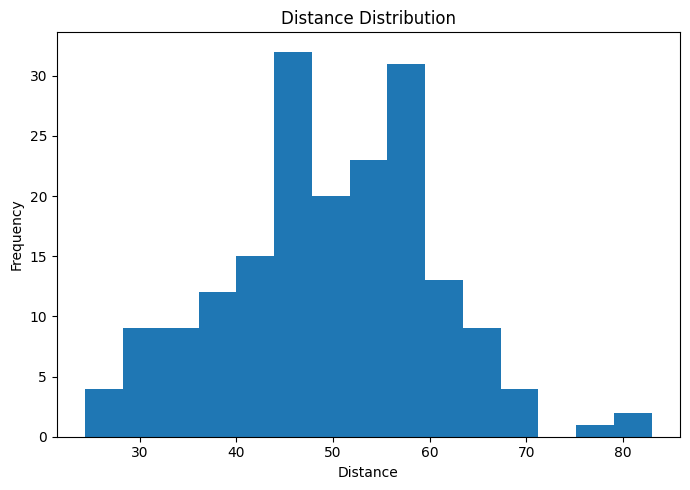

In [10]:
import matplotlib.pyplot as plt

Path("outputs/figures").mkdir(
    parents=True,
    exist_ok=True
)
plt.figure(figsize=(7, 5))

plt.hist(
    distance_fit,
    bins=15
)
plt.title("Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "outputs/figures/distance_histogram.png"
)

plt.show()

### M2: Welch t-test

In [11]:
g1 = X_fit[
    X_fit["group"] == "G1"
]["distance"].dropna()

g2 = X_fit[
    X_fit["group"] == "G2"
]["distance"].dropna()

t_stat, p_value = stats.ttest_ind(
    g1,
    g2,
    equal_var=False
)

print("G1 count:", len(g1))
print("G2 count:", len(g2))

print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

print("H0: Mean distance of G1 = Mean distance of G2")
print("H1: Mean distance of G1 != Mean distance of G2")

if p_value < alpha:
    print("\nReject H0")
else:
    print("\nFail to reject H0")

G1 count: 104
G2 count: 80
t-statistic: 0.7061612423464614
p-value: 0.48105881393425987
H0: Mean distance of G1 = Mean distance of G2
H1: Mean distance of G1 != Mean distance of G2

Fail to reject H0


In [12]:
standard_error = (
    std_distance / np.sqrt(n_distance)
)

t_value = stats.t.ppf(
    0.975,
    df=n_distance - 1
)

margin = t_value * standard_error

lower = mean_distance - margin
upper = mean_distance + margin

print("95% Confidence Interval")
print("Lower:", lower)
print("Upper:", upper)

95% Confidence Interval
Lower: 48.16829889365394
Upper: 51.320505454172164


### M3: Linear algebra

In [13]:
matrix_data = X_fit[
    ["distance", "traffic"]
].dropna()

X_matrix = matrix_data.values

print("Complete rows:", len(X_matrix))

X_centered = (
    X_matrix -
    X_matrix.mean(axis=0)
)

print(X_centered[:5])

n_matrix = len(X_centered)

cov_matrix = (
    X_centered.T @ X_centered
) / (n_matrix - 1)

print("Covariance Matrix:")
print(cov_matrix)

eigenvalues, eigenvectors = np.linalg.eigh(
    cov_matrix
)

print("Eigenvalues:")
print(eigenvalues)

largest_index = np.argmax(eigenvalues)

largest_eigenvalue = (
    eigenvalues[largest_index]
)

variance_share = (
    largest_eigenvalue /
    eigenvalues.sum()
)

principal_direction = (
    eigenvectors[:, largest_index]
)

print("Largest eigenvalue:",
      largest_eigenvalue)

print("Variance share:",
      variance_share)

print("Variance share %:",
      variance_share * 100)

print("Principal direction:",
      principal_direction)

Complete rows: 184
[[  6.10559783  -6.78494565]
 [  2.00559783 -12.83494565]
 [  9.24559783  15.84505435]
 [  8.29559783   3.97505435]
 [  7.85559783 -11.74494565]]
Covariance Matrix:
[[117.41612751  -1.23645741]
 [ -1.23645741 107.43358798]]
Eigenvalues:
[107.28271803 117.56699745]
Largest eigenvalue: 117.5669974540402
Variance share: 0.5228692293455571
Variance share %: 52.28692293455571
Principal direction: [-0.99263792  0.1211196 ]


## Task 2 — Data Preprocessing & Feature Engineering 

### F1 - Audit and pratition (Done at the start of the Notebook)

### F2 — Transform and Engineer

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

numeric_cols = [
    "distance",
    "load",
    "traffic",
    "staff"
]

categorical_cols = [
    "group"
]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['distance', 'load', 'traffic', 'staff']
Categorical: ['group']


In [15]:
imputer = SimpleImputer(
    strategy="median"
)

X_fit_num = imputer.fit_transform(
    X_fit[numeric_cols]
)

X_val_num = imputer.transform(
    X_val[numeric_cols]
)

X_test_num = imputer.transform(
    X_test[numeric_cols]
)

print("Fit shape:", X_fit_num.shape)
print("Validation shape:", X_val_num.shape)
print("Test shape:", X_test_num.shape)

Fit shape: (192, 4)
Validation shape: (48, 4)
Test shape: (60, 4)


In [ ]:
# converting back to df
fit_num_df = pd.DataFrame(
    X_fit_num,
    columns=numeric_cols,
    index=X_fit.index
)

val_num_df = pd.DataFrame(
    X_val_num,
    columns=numeric_cols,
    index=X_val.index
)

test_num_df = pd.DataFrame(
    X_test_num,
    columns=numeric_cols,
    index=X_test.index
)

In [18]:
# Engineer feature
#load / (staff + 1)

fit_num_df["engineered_feature"] = (
    fit_num_df["load"] /
    (fit_num_df["staff"] + 1)
)

val_num_df["engineered_feature"] = (
    val_num_df["load"] /
    (val_num_df["staff"] + 1)
)

test_num_df["engineered_feature"] = (
    test_num_df["load"] /
    (test_num_df["staff"] + 1)
)

print(fit_num_df.head())


     distance    load  traffic  staff  engineered_feature
288     55.85  54.680    42.44  54.95            0.977301
73      51.75  47.550    36.39  36.13            1.280636
259     58.99  38.830    65.07  53.74            0.709353
280     58.04  37.760    53.20  53.97            0.686920
243     57.60  49.965    37.48  57.45            0.854833


In [19]:
# one hot encoding

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

fit_group = encoder.fit_transform(
    X_fit[categorical_cols]
)

val_group = encoder.transform(
    X_val[categorical_cols]
)

test_group = encoder.transform(
    X_test[categorical_cols]
)

group_names = encoder.get_feature_names_out(
    categorical_cols
)

print(group_names)



['group_G1' 'group_G2']


In [ ]:
feature_numeric_cols = [
    "distance",
    "load",
    "traffic",
    "staff",
    "engineered_feature"
]

scaler = StandardScaler()

fit_scaled = scaler.fit_transform(
    fit_num_df[feature_numeric_cols]
)

val_scaled = scaler.transform(
    val_num_df[feature_numeric_cols]
)

test_scaled = scaler.transform(
    test_num_df[feature_numeric_cols]
)

In [21]:
feature_names = (
    feature_numeric_cols +
    list(group_names)
)

X_fit_final = np.hstack([
    fit_scaled,
    fit_group
])

X_val_final = np.hstack([
    val_scaled,
    val_group
])

X_test_final = np.hstack([
    test_scaled,
    test_group
])

print("Fit:", X_fit_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

print("\nFeatures:")
print(feature_names)

Fit: (192, 7)
Validation: (48, 7)
Test: (60, 7)

Features:
['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']


### F3 - Leakage Evidence

In [22]:
print(
    "Fit values finite:",
    np.isfinite(X_fit_final).all()
)

print(
    "Validation values finite:",
    np.isfinite(X_val_final).all()
)

print(
    "Test values finite:",
    np.isfinite(X_test_final).all()
)

Fit values finite: True
Validation values finite: True
Test values finite: True


In [23]:
preprocess_info = pd.DataFrame({
    "feature_name": feature_names
})

preprocess_info.to_csv(
    "outputs/preprocessing_features.csv",
    index=False
)

print(preprocess_info)

         feature_name
0            distance
1                load
2             traffic
3               staff
4  engineered_feature
5            group_G1
6            group_G2


## TASK 3: SUPERVISED LEARNING

### S1 — Baseline and Classifier

In [24]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_fit_final,
    y_fit
)

dummy_pred = dummy_model.predict(
    X_test_final
)

dummy_accuracy = accuracy_score(
    y_test,
    dummy_pred
)

print("Dummy Accuracy:",
      dummy_accuracy)

Dummy Accuracy: 0.5166666666666667


In [27]:
# Logistic regression model

log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(
    X_fit_final,
    y_fit
)

log_pred = log_model.predict(
    X_test_final
)

log_prob = log_model.predict_proba(
    X_test_final
)[:, 1]

print("Logistic Regression trained")

log_accuracy = accuracy_score(
    y_test,
    log_pred
)

log_precision = precision_score(
    y_test,
    log_pred,
    zero_division=0
)

log_recall = recall_score(
    y_test,
    log_pred,
    zero_division=0
)

log_f1 = f1_score(
    y_test,
    log_pred,
    zero_division=0
)

print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)

Logistic Regression trained
Accuracy : 0.85
Precision: 0.8846153846153846
Recall   : 0.7931034482758621
F1 Score : 0.8363636363636363


### S2 — Holdout Evaluation

[[28  3]
 [ 6 23]]


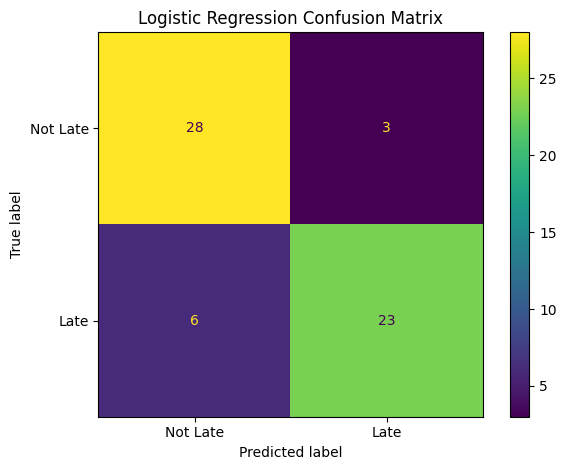

In [28]:
cm = confusion_matrix(
    y_test,
    log_pred
)

print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not Late",
        "Late"
    ]
)

display.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/logistic_confusion_matrix.png"
)

plt.show()

In [29]:
predictions = pd.DataFrame({
    "record_id": X_test["record_id"].values,
    "true_label": y_test.values,
    "predicted_label": log_pred,
    "class_1_probability": log_prob
})

predictions.to_csv(
    "outputs/logistic_predictions.csv",
    index=False
)

print(predictions.head())

   record_id  true_label  predicted_label  class_1_probability
0         50           0                0             0.034625
1        231           0                0             0.074453
2        297           0                0             0.006790
3         97           0                0             0.112015
4        285           0                0             0.040311


### S3 — Interpretation 

In [30]:
model_results = pd.DataFrame({
    "model": [
        "Dummy Classifier",
        "Logistic Regression"
    ],

    "accuracy": [
        dummy_accuracy,
        log_accuracy
    ],

    "precision": [
        np.nan,
        log_precision
    ],

    "recall": [
        np.nan,
        log_recall
    ],

    "f1": [
        np.nan,
        log_f1
    ]
})

print(model_results)

                 model  accuracy  precision    recall        f1
0     Dummy Classifier  0.516667        NaN       NaN       NaN
1  Logistic Regression  0.850000   0.884615  0.793103  0.836364


## Task 4 — Unsupervised Learning

### U1 — K-Means and Selection

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_data = fit_scaled

print("Clustering shape:",
      cluster_data.shape)

k_results = []

for k in [2, 3, 4]:

    model = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(
        cluster_data
    )

    inertia = model.inertia_

    silhouette = silhouette_score(
        cluster_data,
        labels
    )

    k_results.append([
        k,
        inertia,
        silhouette
    ])

k_results = pd.DataFrame(
    k_results,
    columns=[
        "k",
        "inertia",
        "silhouette"
    ]
)

print(k_results)

Clustering shape: (192, 5)
   k     inertia  silhouette
0  2  719.632089    0.246337
1  3  599.659398    0.207147
2  4  535.383548    0.190232


C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Program Files\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as

### U2 — Segment Interpretation

In [32]:
best_k = k_results.sort_values(
    by=["silhouette", "k"],
    ascending=[False, True]
).iloc[0]["k"]

best_k = int(best_k)

print("Best k:", best_k)

Best k: 2


In [33]:
final_kmeans = KMeans(
    n_clusters=best_k,
    n_init=10,
    random_state=42
)

cluster_labels = final_kmeans.fit_predict(
    cluster_data
)

fit_num_df["cluster"] = cluster_labels

print(
    fit_num_df["cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile = fit_num_df.groupby(
    "cluster"
)[feature_numeric_cols].mean()

print(cluster_profile)

cluster
0    134
1     58
Name: count, dtype: int64
          distance       load    traffic      staff  engineered_feature
cluster                                                                
0        48.418955  47.127985  49.066269  54.035000            0.863256
1        52.869483  57.461552  49.856207  41.426724            1.372952


In [34]:
k_results.to_csv(
    "outputs/kmeans_scores.csv",
    index=False
)

cluster_profile.to_csv(
    "outputs/cluster_profiles.csv"
)

cluster_output = pd.DataFrame({
    "record_id": X_fit["record_id"].values,
    "cluster": cluster_labels
})

cluster_output.to_csv(
    "outputs/cluster_assignments.csv",
    index=False
)

print("Clustering files saved")

Clustering files saved


## Task 5 — Deep Learning up to ANN 

### D1 — ANN Architecture and Compilation 

In [35]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

print("TensorFlow seed set to 42")

TensorFlow seed set to 42


In [36]:
# Input → 16 ReLU → 8 ReLU → 1 Sigmoid

input_size = X_fit_final.shape[1]

ann = Sequential([
    Dense(
        16,
        activation="relu",
        input_shape=(input_size,)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=["accuracy"]
)

ann.summary()

C:\Users\MAITRAK\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
trainable_params = 0

for variable in ann.trainable_variables:
    trainable_params += np.prod(
        variable.shape
    )

print(
    "Trainable parameters:",
    trainable_params
)

Trainable parameters: 273


In [38]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

### D2 — Training and Validation

In [39]:
history = ann.fit(
    X_fit_final,
    y_fit,

    validation_data=(
        X_val_final,
        y_val
    ),

    epochs=50,
    batch_size=16,

    callbacks=[
        early_stop
    ],

    verbose=1
)

print(
    "Actual epochs:",
    len(history.history["loss"])
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4792 - loss: 0.7045 - val_accuracy: 0.4792 - val_loss: 0.6981
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5156 - loss: 0.6895 - val_accuracy: 0.5000 - val_loss: 0.6919
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5312 - loss: 0.6768 - val_accuracy: 0.5417 - val_loss: 0.6854
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5885 - loss: 0.6649 - val_accuracy: 0.6042 - val_loss: 0.6786
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6562 - loss: 0.6529 - val_accuracy: 0.6250 - val_loss: 0.6711
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7240 - loss: 0.6408 - val_accuracy: 0.6250 - val_loss: 0.6629
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7656 - loss: 0.6285 - val_accuracy: 0.6667 - val_loss: 0.6542
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8021 - loss: 0.6157 - val_accuracy: 0.6667 - val_loss

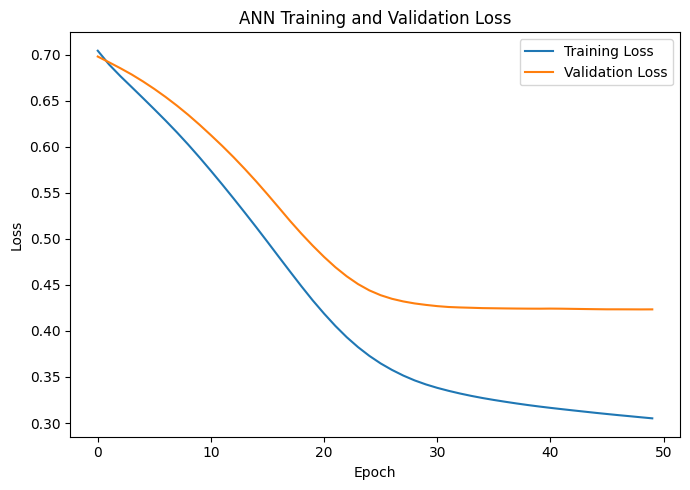

In [40]:
plt.figure(figsize=(7, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ANN Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/ann_loss_curve.png"
)

plt.show()

In [42]:
# testing ann
ann_prob = ann.predict(
    X_test_final
).ravel()

ann_pred = (
    ann_prob >= 0.5
).astype(int)

print(ann_pred[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
[0 0 0 0 0 1 1 0 1 0]


In [43]:
# ANN metrics

ann_accuracy = accuracy_score(
    y_test,
    ann_pred
)

ann_precision = precision_score(
    y_test,
    ann_pred,
    zero_division=0
)

ann_recall = recall_score(
    y_test,
    ann_pred,
    zero_division=0
)

ann_f1 = f1_score(
    y_test,
    ann_pred,
    zero_division=0
)

print("Accuracy :", ann_accuracy)
print("Precision:", ann_precision)
print("Recall   :", ann_recall)
print("F1 Score :", ann_f1)

Accuracy : 0.8333333333333334
Precision: 0.8518518518518519
Recall   : 0.7931034482758621
F1 Score : 0.8214285714285714


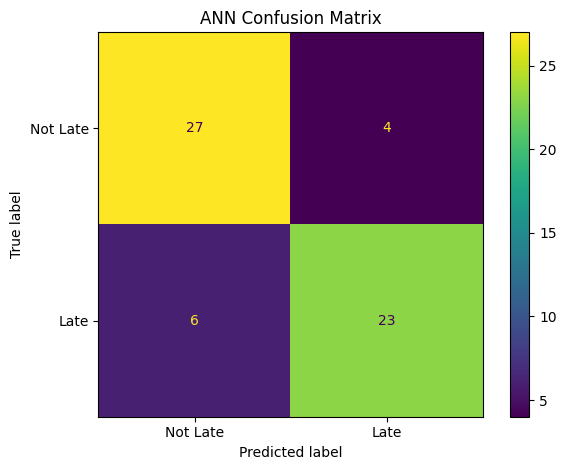

In [44]:
# ANN confusion matrix

ann_cm = confusion_matrix(
    y_test,
    ann_pred
)

display = ConfusionMatrixDisplay(
    confusion_matrix=ann_cm,
    display_labels=[
        "Not Late",
        "Late"
    ]
)

display.plot()

plt.title(
    "ANN Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    "outputs/figures/ann_confusion_matrix.png"
)

plt.show()

In [45]:
ann_predictions = pd.DataFrame({
    "record_id": X_test["record_id"].values,
    "true_label": y_test.values,
    "predicted_label": ann_pred,
    "class_1_probability": ann_prob
})

ann_predictions.to_csv(
    "outputs/ann_predictions.csv",
    index=False
)

print(ann_predictions.head())

   record_id  true_label  predicted_label  class_1_probability
0         50           0                0             0.076672
1        231           0                0             0.074701
2        297           0                0             0.015147
3         97           0                0             0.200545
4        285           0                0             0.102047


### D3 — Comparison and Evidence 

In [46]:
# comparing all models

comparison = pd.DataFrame({
    "model": [
        "Dummy Classifier",
        "Logistic Regression",
        "ANN"
    ],

    "accuracy": [
        dummy_accuracy,
        log_accuracy,
        ann_accuracy
    ],

    "precision": [
        np.nan,
        log_precision,
        ann_precision
    ],

    "recall": [
        np.nan,
        log_recall,
        ann_recall
    ],

    "f1": [
        np.nan,
        log_f1,
        ann_f1
    ]
})

print(comparison)

                 model  accuracy  precision    recall        f1
0     Dummy Classifier  0.516667        NaN       NaN       NaN
1  Logistic Regression  0.850000   0.884615  0.793103  0.836364
2                  ANN  0.833333   0.851852  0.793103  0.821429


In [47]:
# compare logistic and ann

print("Logistic Regression F1:",
      log_f1)

print("ANN F1:",
      ann_f1)

if ann_f1 > log_f1:
    print("\nANN has higher F1 on the test set.")
else:
    print("\nLogistic Regression has higher F1 on the test set.")

Logistic Regression F1: 0.8363636363636363
ANN F1: 0.8214285714285714

Logistic Regression has higher F1 on the test set.


In [49]:
# save model comparison

comparison.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

In [51]:
# save ANN
Path("models").mkdir(parents=True, exist_ok=True)

ann.save(
    "models/ann_model.keras"
)

print("ANN model saved")

ANN model saved


In [52]:
# Saving statistics

statistics_summary = pd.DataFrame({
    "metric": [
        "distance_n",
        "distance_mean",
        "distance_median",
        "distance_std",
        "welch_t_stat",
        "welch_p_value",
        "ci_lower",
        "ci_upper",
        "largest_eigenvalue",
        "variance_share"
    ],

    "value": [
        n_distance,
        mean_distance,
        median_distance,
        std_distance,
        t_stat,
        p_value,
        lower,
        upper,
        largest_eigenvalue,
        variance_share
    ]
})

statistics_summary.to_csv(
    "outputs/statistics_summary.csv",
    index=False
)

print(statistics_summary)

               metric       value
0          distance_n  184.000000
1       distance_mean   49.744402
2     distance_median   50.200000
3        distance_std   10.835872
4        welch_t_stat    0.706161
5       welch_p_value    0.481059
6            ci_lower   48.168299
7            ci_upper   51.320505
8  largest_eigenvalue  117.566997
9      variance_share    0.522869


In [53]:
# checking important outputs

print("========== FINAL CHECK ==========")

print("\nDataset")
print("Original:", len(df))
print("Clean:", len(df_clean))

print("\nPartitions")
print("Fit:", len(X_fit))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nLogistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)

print("\nANN")
print("Accuracy:", ann_accuracy)
print("Precision:", ann_precision)
print("Recall:", ann_recall)
print("F1:", ann_f1)

print("\nK-Means")
print("Best k:", best_k)

print("\nANN epochs:",
      len(history.history["loss"]))

========== FINAL CHECK ==========

Dataset
Original: 305
Clean: 300

Partitions
Fit: 192
Validation: 48
Test: 60

Logistic Regression
Accuracy: 0.85
Precision: 0.8846153846153846
Recall: 0.7931034482758621
F1: 0.8363636363636363

ANN
Accuracy: 0.8333333333333334
Precision: 0.8518518518518519
Recall: 0.7931034482758621
F1: 0.8214285714285714

K-Means
Best k: 2

ANN epochs: 50
